In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
rfm = pd.read_csv('Data/Processed/rfm_table.csv')

In [38]:
rfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer ID  5878 non-null   float64
 1   Recency      5878 non-null   int64  
 2   Frequency    5878 non-null   int64  
 3   Monetary     5878 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 183.8 KB


In [39]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,2955.904095
std,1715.572666,209.338707,13.009406,14440.852688
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,342.280000
50%,15314.500000,96.000000,3.000000,867.740000
75%,16797.750000,380.000000,7.000000,2248.305000
max,18287.000000,739.000000,398.000000,580987.040000


In [40]:
rfm['churn'] = (rfm['Recency'] > 180).astype(int)

In [41]:
rfm['churn'].value_counts()

churn
0    3478
1    2400
Name: count, dtype: int64

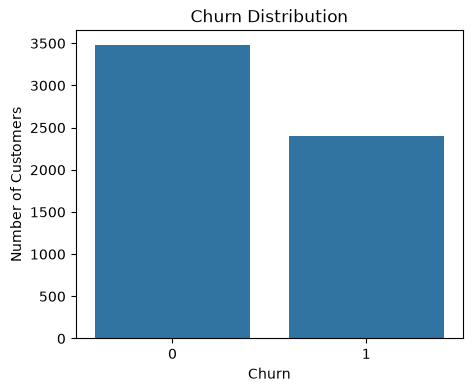

In [42]:
plt.figure(figsize=(5,4))

sns.countplot(
    data=rfm,
    x="churn"
)

plt.title("Churn Distribution")

plt.xlabel("Churn")

plt.ylabel("Number of Customers")

plt.show()

Class percentages:

Active: ≈59.2%
Churned: ≈40.8%

This is not highly imbalanced, so we do not need techniques like SMOTE or undersampling. A standard Random Forest should work well.

In [44]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['churn']

In [45]:
print(X.head())

print(y.head())

   Recency  Frequency  Monetary
0      326         12  77556.46
1        2          8   4921.53
2       75          5   2019.40
3       19          4   4428.69
4      310          1    334.40
0    1
1    0
2    0
3    0
4    1
Name: churn, dtype: int64


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [47]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)


(4702, 3)
(1176, 3)
(4702,)
(1176,)


In [48]:
# Random forest classifier 
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [49]:
y_pred = rf_model.predict(X_test)

In [50]:
# prediction probability 
# We need probabilities later for ROC-AUC
y_prob = rf_model.predict_proba(X_test)[:,1]

In [51]:
# calculate accuracy 
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9991496598639455


In [ ]:
# classification report 
#This gives Precision, Recall and F1-score
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       696
           1       1.00      1.00      1.00       480

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [53]:
# confusion metrices 
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[696   0]
 [  1 479]]


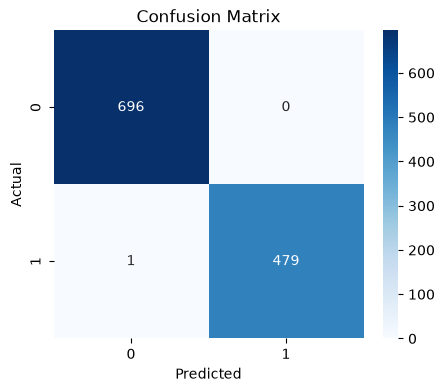

In [54]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [55]:
# ROC-AUC score 
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", auc)

ROC-AUC: 1.0


## Churn Prediction Summary

A Random Forest classifier was developed to identify customers at risk of churn.

Since the Online Retail dataset does not contain an explicit churn label, a business rule was used to generate the target variable:

• Churn = 1 if Recency > 180 days
• Churn = 0 otherwise

The model achieved:

• Accuracy : 99.91%
• ROC-AUC : 1.00

The high performance is expected because the churn label is derived directly from the Recency feature, which is also used as an input to the model. This demonstrates the complete churn prediction workflow but should not be interpreted as real-world predictive performance.

In [56]:
# feature importaance 
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,Recency,0.849637
1,Frequency,0.080801
2,Monetary,0.069562


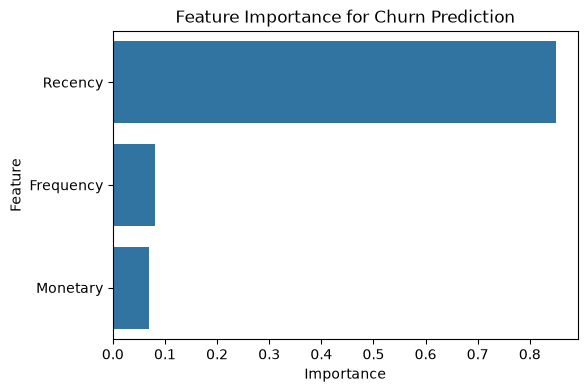

In [57]:


plt.figure(figsize=(6,4))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance for Churn Prediction")

plt.show()

Inventory Optimization

This module converts your forecasted demand into business decisions.